# Getting your data into ehrapy

ehrapy analyzes electronic health records (EHR) stored in an {class}`~ehrdata.EHRData` object, which holds patients × variables × time.
This tutorial reads the 100 patients of the [MIMIC-IV Clinical Database Demo](https://physionet.org/content/mimic-iv-demo-meds/0.0.1/) in the [Medical Event Data Standard (MEDS)](https://medical-event-data-standard.github.io) {cite}`goldberger2000physiobank`.
On this real hospital data we look at how EHRData organizes static and time-varying information, annotate the clinical codes, prepare the laboratory values, take first steps with ehrapy and save the result.

## Environment setup

In [1]:
import tempfile
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed

ep.settings.verbosity = "error"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
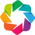

In [3]:
import holoviews as hv

hv.extension("bokeh")

## Reading the data

MEDS stores one row per event: a patient, a time, a code such as a laboratory test or a diagnosis, and optionally a numeric value.
{func}`~ehrdata.dt.mimic_iv_meds` downloads the demo and reads it with {func}`~ehrdata.io.read_meds`, which bins the events of every patient into 14 days starting at the first hospital admission.

In [4]:
edata = ed.dt.mimic_iv_meds()
edata

EHRData object with n_obs × n_vars × n_t = 100 × 4253 × 14
    obs: 'split', 'anchor_time', 'gender', 'age', 'death'
    var: 'n_events', 'description'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13'
    shape of .X: (100, 4253, 14)

:::{admonition} Reading your own data
:class: seealso
A table with one column per variable goes through {func}`~ehrdata.io.from_pandas`, and a long table with one row per event, as most EHR systems export it, through {func}`~ehrdata.io.from_events`.
MEDS datasets are read with {func}`~ehrdata.io.read_meds`, FHIR R4 exports with {func}`~ehrdata.io.read_fhir` and OMOP CDM databases with the functions in {doc}`ed.io.omop <ehrdata:api/io_index>`, starting with {func}`~ehrdata.io.omop.setup_connection`.
Saved objects are read back with {func}`~ehrdata.io.read_h5ed` and {func}`~ehrdata.io.read_zarr`.
The ehrdata tutorial {doc}`Reading EHR data <ehrdata:tutorials/reading_data>` runs every reader end to end, and the {doc}`ehrdata API <ehrdata:api/io_index>` lists all of them.
:::

:::{note}
{doc}`ed.dt <ehrdata:api/datasets_index>` ships real public datasets, which the ehrapy tutorials use: the ICU stays of the PhysioNet 2012 and 2019 challenges, the MIMIC-II IAC cohort, the eICU and MIMIC-IV demos, follow-up visits of primary biliary cholangitis, and heart failure and heart disease cohorts.
They are listed in the {doc}`ehrdata datasets API <ehrdata:api/datasets_index>`.
:::

## The data model

`.X` holds the time-varying data as a 3D array of patients × variables × timepoints.
Here the variables are 4,253 codes and the timepoints are 14 days.

In [5]:
edata.X.shape

(100, 4253, 14)

Codes with a value, such as laboratory tests, hold the last value of the day, and codes without a value, such as diagnoses or the start of a medication, hold the number of events on that day.
A day without an event of a code is missing (`NaN`).

`.tem` describes the time axis with one row per timepoint.
`time_value` is the start of every interval, here in days since the first admission, and ehrapy functions that need the time of a timepoint read it from there.

In [6]:
edata.tem.head()

,interval_start_offset,interval_end_offset,time_value
interval_step,,,
0,0 days,1 days,0.0
1,1 days,2 days,1.0
2,2 days,3 days,2.0
3,3 days,4 days,3.0
4,4 days,5 days,4.0


`obs` holds one row per patient with the static variables, which do not change over time, such as gender, age at admission and whether a death was recorded.
`anchor_time` is the first admission at which the time axis starts, and `split` is the train, tuning and held-out split that MEDS datasets come with.
We add readable labels of the death indicator for plots.

In [7]:
edata.obs["died"] = edata.obs["death"].map({0: "no", 1: "yes"}).astype("category")
edata.obs.head()

,split,anchor_time,gender,age,death,died
10000032,train,2180-05-06 22:23:00,female,52.344969,1,yes
10001217,train,2157-11-18 22:56:00,female,55.879535,0,no
10001725,tuning,2110-04-11 15:08:00,female,46.272416,0,no
10002428,train,2155-07-14 19:15:00,female,80.528405,0,no
10002495,train,2141-05-22 20:17:00,male,81.385352,0,no


`var` holds one row per variable, here the number of binned events of every code and its description.

In [8]:
edata.var.sort_values("n_events", ascending=False).head()

,n_events,description
LAB//227969//UNK,9764,NaN
LAB//220210//insp/min,6809,NaN
LAB//220045//bpm,6806,NaN
LAB//220277//%,6667,NaN
SUBJECT_WEIGHT_AT_INFUSION//KG,6430,NaN


The most frequent codes are measurements charted in the ICU, which the MEDS conversion files as `LAB` codes without a description.

## Annotating codes

The variables are codes of standard vocabularies, such as `DIAGNOSIS//ICD//10//I10` for essential hypertension in ICD-10-CM or the NDC of a drug at the end of `MEDICATION` codes.
{func}`~ehrdata.annotate_codes` adds the vocabulary, the code and, for diagnoses, the ICD chapter and category to `var`.

In [9]:
ed.annotate_codes(edata)
edata.var["vocabulary"].value_counts().head()

vocabulary
NDC         1332
ICD9CM       383
ICD10CM      230
ICD9Proc      69
ICD10PCS      59
Name: count, dtype: Int64

MIMIC-IV spans the switch from ICD-9 to ICD-10 in 2015, so the same disease appears under two vocabularies.
The ICD category finds hypertension in both.

In [10]:
hypertension = edata.var["icd_category"].isin(["ICD9CM/401", "ICD10CM/I10"])
edata.var.loc[hypertension, ["description", "vocabulary", "icd_chapter", "icd_category", "n_events"]]

,description,vocabulary,icd_chapter,icd_category,n_events
DIAGNOSIS//ICD//10//I10,Essential (primary) hypertension,ICD10CM,ICD10CM/I00-I99,ICD10CM/I10,10
DIAGNOSIS//ICD//9//4019,Unspecified essential hypertension,ICD9CM,ICD9CM/390-459,ICD9CM/401,33


:::{note}
The MEDS conversion of MIMIC-IV dates diagnoses at the discharge of an admission, so diagnoses of admissions that end after the 14 days have no events here.
{func}`~ehrdata.aggregate_codes` merges all codes of one category, such as `icd_category`, into a single variable.
:::

## Selecting variables

{func}`~ehrapy.preprocessing.qc_metrics` adds quality metrics of every variable to `var` and of every patient to `obs`.
Times such as the median interval between two values of a variable are read from `time_value`, so they are in days.

In [11]:
ep.pp.qc_metrics(edata)
edata.obs[["measured_timepoints_abs", "last_measured_time"]].describe().round(1)

,measured_timepoints_abs,last_measured_time
count,100.0,100.0
mean,7.6,7.7
std,3.9,4.1
min,1.0,0.0
25%,4.8,4.0
50%,7.0,7.0
75%,10.0,12.0
max,14.0,13.0


Patients have values on a median of 7 of the 14 days, since most leave the hospital before the end of the time axis.
We keep the hospital laboratory tests, which come with a description, that were measured in at least 90% of the patients.
Their codes end with the unit, which we keep in `var`, and the short name of the description becomes the variable name.

In [12]:
is_lab = edata.var_names.str.startswith("LAB//") & edata.var["description"].notna()
edata = edata[:, is_lab & (edata.var["measured_obs_pct"] >= 90)].copy()
edata.var["unit"] = edata.var_names.str.split("//").str[-1]
edata.var_names = edata.var["description"].str.split(r" \[| in | by ", regex=True).str[0].to_numpy()
edata.var[["description", "unit", "measured_obs_pct", "median_interval"]]

,description,unit,measured_obs_pct,median_interval
Anion gap 4,Anion gap 4 in Serum or Plasma,mEq/L,94.0,1.0
Bicarbonate,Bicarbonate [Moles/volume] in Serum or Plasma,mEq/L,94.0,1.0
Calcium,Calcium [Mass/volume] in Serum or Plasma,mg/dL,92.0,1.0
Chloride,Chloride [Moles/volume] in Serum or Plasma,mEq/L,97.0,1.0
Creatinine,Creatinine [Mass/volume] in Serum or Plasma,mg/dL,97.0,1.0
Glucose,Glucose [Mass/volume] in Serum or Plasma,mg/dL,94.0,1.0
Magnesium,Magnesium [Mass/volume] in Serum or Plasma,mg/dL,93.0,1.0
Phosphate,Phosphate [Mass/volume] in Serum or Plasma,mg/dL,91.0,1.0
Potassium,Potassium [Moles/volume] in Serum or Plasma,mEq/L,97.0,1.0
Sodium,Sodium [Moles/volume] in Serum or Plasma,mEq/L,97.0,1.0


The 19 tests are the basic metabolic panel with magnesium and phosphate and the complete blood count, which are drawn about once a day.
{func}`~ehrapy.plot.timeseries` shows the creatinine of three patients over the 14 days.

In [13]:
ep.pl.timeseries(
    edata,
    obs_names=["10029291", "10038081", "10000032"],
    var_names="Creatinine",
    overlay=True,
    xlabel="day",
    ylabel="creatinine (mg/dL)",
    title="Creatinine",
)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Overlay
   .Curve.A_10029291 :Curve   [time]   (value,variable)
   .Scatter.I        :Scatter   [time]   (value,variable)
   .Curve.A_10038081 :Curve   [time]   (value,variable)
   .Scatter.II       :Scatter   [time]   (value,variable)
   .Curve.A_10000032 :Curve   [time]   (value,variable)
   .Scatter.III      :Scatter   [time]   (value,variable)

The creatinine of the first patient rises from 2.4 to 6.4 mg/dL by day 4 and peaks again on day 8, signs of acute kidney injury, before it falls to 1.9 mg/dL by day 13.
The second patient is stable in the first week and rises to 3.9 mg/dL in the second, while the third has a single value on the day of admission and is missing on all later days.

## Feature types

ehrapy treats numeric, categorical and date variables differently, for instance when it encodes, imputes or tests them.
{func}`~ehrdata.infer_feature_types` infers the type of every variable from its values and stores it in `var["feature_type"]`, and {func}`~ehrdata.feature_type_overview` shows the result.

In [14]:
ed.infer_feature_types(edata, output=None)
ed.feature_type_overview(edata)

 Detected feature types for EHRData object with 100 obs and 19 vars
╠══ 📅 Date features
╠══ 📐 Numerical features
║   ╠══ Anion gap 4
║   ╠══ Bicarbonate
║   ╠══ Calcium
║   ╠══ Chloride
║   ╠══ Creatinine
║   ╠══ Erythrocyte distribution width
║   ╠══ Erythrocytes
║   ╠══ Glucose
║   ╠══ Hematocrit
║   ╠══ Hemoglobin
║   ╠══ Leukocytes
║   ╠══ MCH
║   ╠══ MCV
║   ╠══ Magnesium
║   ╠══ Phosphate
║   ╠══ Platelets
║   ╠══ Potassium
║   ╠══ Sodium
║   ╚══ Urea nitrogen
╚══ 🗂️ Categorical features

:::{important}
The inference is a guess from the values.
Codes without a value count events and are numeric, while integer codes with few distinct values, such as scores, may be detected as categorical.
Correct wrong guesses with {func}`~ehrdata.replace_feature_types`.
:::

## First steps

We embed the patients by their laboratory values on the first three days, which most patients spend in the hospital.
The third index of an EHRData object selects timepoints.

In [15]:
early = edata[:, :, :3].copy()
early

EHRData object with n_obs × n_vars × n_t = 100 × 19 × 3
    obs: 'split', 'anchor_time', 'gender', 'age', 'death', 'died', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'measured_timepoints_abs', 'measured_timepoints_pct', 'first_measured_time', 'last_measured_time'
    var: 'n_events', 'description', 'vocabulary', 'code', 'icd_chapter', 'icd_category', 'icd_codes', 'atc_level_1', 'atc_level_2', 'atc_level_3', 'atc_level_4', 'atc_level_5', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'mean', 'median', 'standard_deviation', 'min', 'max', 'iqr_outliers', 'measured_obs_pct', 'median_interval', 'unit', 'feature_type'
    tem: '0', '1', '2'
    shape of .X: (100, 19, 3)

The embedding needs a value on every day, so {func}`~ehrapy.preprocessing.locf_impute` carries the last value forward and fills days before the first value with the mean.
We impute and scale in a layer, which has the shape of `.X`, so that `.X` keeps the observed values.
{func}`~ehrapy.preprocessing.pca` then runs on the 3D data, {func}`~ehrapy.preprocessing.neighbors` connects every patient to the most similar ones, and {func}`~ehrapy.tools.umap` embeds this graph in two dimensions {cite}`McInnes2018`.

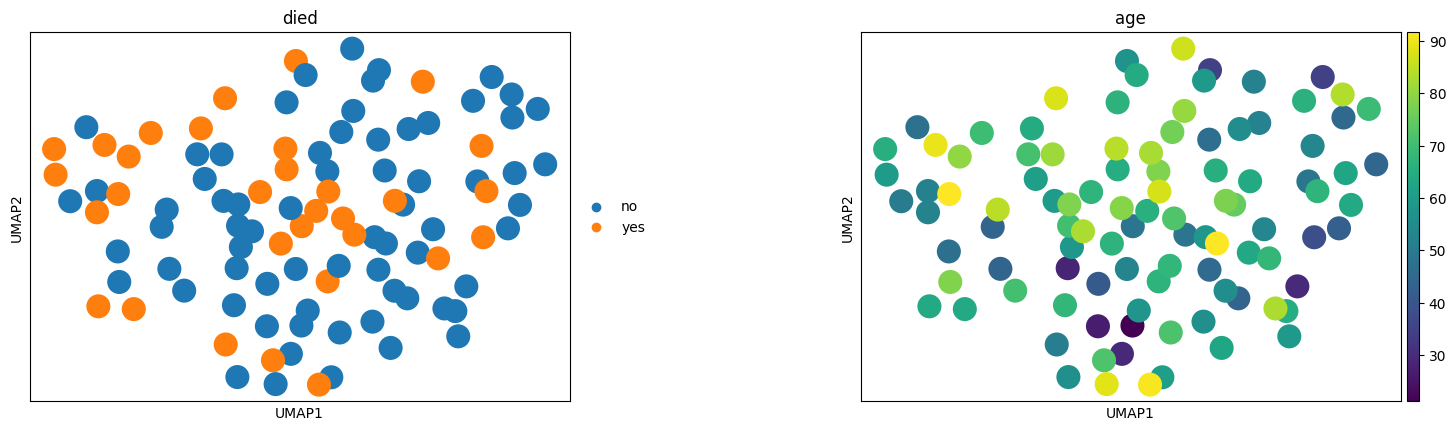

In [16]:
early.layers["scaled"] = early.X.copy()
ep.pp.locf_impute(early, layer="scaled", fallback_method="mean")
ep.pp.scale_norm(early, layer="scaled")
ep.pp.pca(early, layer="scaled", n_comps=20)
ep.pp.neighbors(early, n_neighbors=10)
ep.tl.umap(early)
ep.pl.umap(early, color=["died", "age"], wspace=0.4)

Patients who died spread across the embedding, and with 100 patients it is a first look rather than a finding.

### Where results are stored

In [17]:
early

EHRData object with n_obs × n_vars × n_t = 100 × 19 × 3
    obs: 'split', 'anchor_time', 'gender', 'age', 'death', 'died', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'measured_timepoints_abs', 'measured_timepoints_pct', 'first_measured_time', 'last_measured_time'
    var: 'n_events', 'description', 'vocabulary', 'code', 'icd_chapter', 'icd_category', 'icd_codes', 'atc_level_1', 'atc_level_2', 'atc_level_3', 'atc_level_4', 'atc_level_5', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'mean', 'median', 'standard_deviation', 'min', 'max', 'iqr_outliers', 'measured_obs_pct', 'median_interval', 'unit', 'feature_type'
    tem: '0', '1', '2'
    uns: 'normalization', 'pca', 'neighbors', 'umap', 'died_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: 'scaled'
    shape of .X: (100, 19, 3)
    shape of .scaled: (100, 19, 3)

ehrapy stores every result next to what it describes.
Per-patient results go into `obs`, such as the quality metrics, or into `obsm` if they have several columns, such as the principal components in `X_pca` and the UMAP coordinates in `X_umap`.
Per-variable results go into `var` and `varm`, such as the loadings of every variable and day on the principal components in `PCs`.
Relations between patients, such as the neighborhood graph, go into `obsp`.
`uns` only holds what fits nowhere else, such as the parameters of a run.

## Saving

Reading raw exports takes time, so we save the object with {func}`~ehrdata.io.write_h5ed` in a single HDF5 file and read it back with {func}`~ehrdata.io.read_h5ed`.

In [18]:
path = Path(tempfile.mkdtemp()) / "mimic_iv_demo_labs.h5ed"
ed.io.write_h5ed(early, path)
ed.io.read_h5ed(path)

EHRData object with n_obs × n_vars × n_t = 100 × 19 × 3
    obs: 'split', 'anchor_time', 'gender', 'age', 'death', 'died', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'measured_timepoints_abs', 'measured_timepoints_pct', 'first_measured_time', 'last_measured_time'
    var: 'n_events', 'description', 'vocabulary', 'code', 'icd_chapter', 'icd_category', 'icd_codes', 'atc_level_1', 'atc_level_2', 'atc_level_3', 'atc_level_4', 'atc_level_5', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'mean', 'median', 'standard_deviation', 'min', 'max', 'iqr_outliers', 'measured_obs_pct', 'median_interval', 'unit', 'feature_type'
    tem: '0', '1', '2'
    uns: 'died_colors', 'neighbors', 'normalization', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'scaled'
    shape of .X: (100, 19, 3)
    shape of .scaled: (100, 19, 3)

:::{tip}
Use {func}`~ehrdata.io.write_zarr` instead for large data and cloud object storage.
Neither format stores datetime columns, so convert them to strings before saving.
:::

## Conclusion

An EHRData object holds the time-varying values of every patient in a 3D `.X`, alternative versions of them in `layers`, the time axis in `.tem`, static variables in `obs` and variable annotations in `var`.
Every ehrapy function reads from and writes to these slots, so data from any of the ehrdata readers is ready for the analyses in the other tutorials.